<a href="https://colab.research.google.com/github/Yadav1218/colab/blob/main/515.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install pandas openpyxl

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
sns.set_style('whitegrid') #注意！set_style會蓋過matplotlib的中文字型設定，所以要先執行
# matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或者 'SimHei' 'JhengHei'等
# matplotlib.rcParams['axes.unicode_minus'] = False  # 顯示負號

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#df = pd.read_csv('C:/Users/User/Downloads/Ecommerce_Consumer_Behavior_Analysis_Data.csv')
df = pd.read_csv("/content/drive/MyDrive/資料分析/Ecommerce_Consumer_Behavior_Analysis_Data.csv")
df.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status',
       'Education_Level', 'Occupation', 'Location', 'Purchase_Category',
       'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel',
       'Brand_Loyalty', 'Product_Rating',
       'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence',
       'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction',
       'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method',
       'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member',
       'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision'],
      dtype='object')

In [ ]:
# 將 Gender 過濾只保留 Male 和 Female
data = df[df["Gender"].isin(["Male", "Female"])]
# 將資料依照 Age 由小到大排序
df_sorted = data.sort_values(by="Age")
# 顯示前幾筆排序後的資料
#df_sorted[["Gender", "Age", "Purchase_Amount"]].head(20)

In [ ]:
#前置作業
# 去除消費金額Purchase_Amount欄位的 $ 及 , 符號
data['Purchase_Amount'] = data['Purchase_Amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)
data.loc[:, 'Purchase_Amount'] = data['Purchase_Amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)
data['Purchase_Amount'] = data['Purchase_Amount'].replace({'\$': '', ',': ''}, regex=True).infer_objects(copy=False).astype(float)
data.loc[:, 'Purchase_Amount'] = data['Purchase_Amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)


In [ ]:
#修正Social_Media_Influence的排序
social_media_order = ['Low', 'Medium', 'High']
data.loc[:, 'Social_Media_Influence'] = pd.Categorical(data['Social_Media_Influence'], categories=social_media_order, ordered=True)

In [ ]:
print(data['Social_Media_Influence'].unique())
print(data['Social_Media_Influence'].unique())

[nan 'Medium' 'Low' 'High']
[nan 'Medium' 'Low' 'High']


In [ ]:
#製作Social_Media_Score 數值欄位
social_score = {
    'NaN': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3
}
data.loc[:, 'Social_Media_Score'] = data['Social_Media_Influence'].replace({None: 'NaN'}).map(social_score).fillna(0).astype(int)
# 檢查
#data[['Social_Media_Influence', 'Social_Media_Score']].head()

/tmp/ipython-input-8-1148134641.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Social_Media_Score'] = data['Social_Media_Influence'].replace({None: 'NaN'}).map(social_score).fillna(0).astype(int)


In [ ]:
#製作Engagement_with_Ads_Score 數值欄位
ads_score = {
    'NaN': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3
}
data.loc[:, 'Engagement_with_Ads_Score'] = data['Engagement_with_Ads'].replace({None: 'NaN'}).map(ads_score).fillna(0).astype(int)
# 將 NaN 替換為 'NaN' 以便顯式處理，然後應用映射
# 檢查
#data[['Social_Media_Influence', 'Social_Media_Score']].head()

/tmp/ipython-input-9-1841976883.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Engagement_with_Ads_Score'] = data['Engagement_with_Ads'].replace({None: 'NaN'}).map(ads_score).fillna(0).astype(int)


In [ ]:
# 製作年齡層Age_Group 類別欄位
age_bins = [18, 22, 28, 35, 100]
age_labels = ['(18~22)', '(22~28)', '(28~35)', '(35+)']
#data['Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)
data.loc[:, 'Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)

/tmp/ipython-input-10-4097213052.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)


In [ ]:
# 計算每個年齡段的總購買金額和消費次數
age_group_stats = data.groupby('Age_Group').agg(
    total_purchase=('Purchase_Amount', 'sum'),
    total_frequency=('Frequency_of_Purchase', 'sum')
)

# 計算每個年齡段的平均購買金額和平均消費次數
age_group_stats['avg_purchase'] = age_group_stats['total_purchase'] / age_group_stats['total_frequency']
age_group_stats['avg_frequency'] = age_group_stats['total_frequency'] / data['Age_Group'].value_counts()

# 可以綜合考慮這兩個指標（例如，將它們相乘來估算總消費力）
age_group_stats['consumption_power'] = age_group_stats['avg_purchase'] * age_group_stats['avg_frequency']

# 找出消費力最高的年齡段
highest_consumption_age_group = age_group_stats['consumption_power'].idxmax()
highest_consumption_power = age_group_stats['consumption_power'].max()

# 顯示結果
print(f"綜合消費力最高的年齡段是: {highest_consumption_age_group}，消費力為: {highest_consumption_power:.2f}")

綜合消費力最高的年齡段是: (28~35)，消費力為: 287.31


/tmp/ipython-input-11-1401569559.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = data.groupby('Age_Group').agg(


C:\Users\User\AppData\Local\Temp\ipykernel_15352\1785362012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_stats.index, y=age_stats['consumption_power'], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_15352\1785362012.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


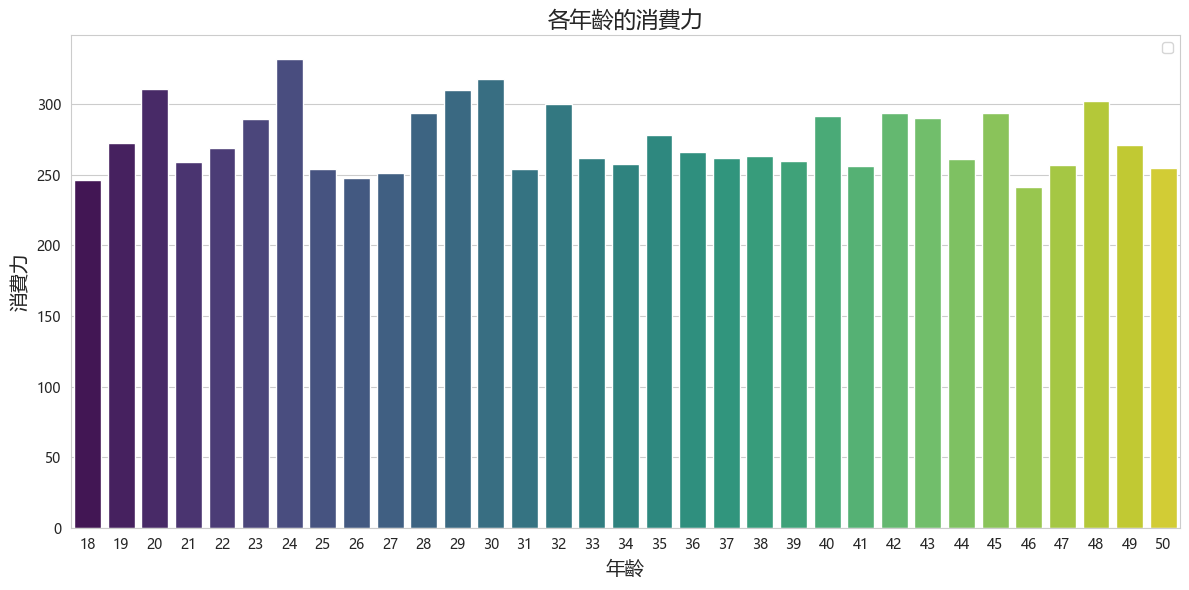

In [ ]:
# 繪製條形圖，顯示每個年齡的消費力
plt.figure(figsize=(12, 6))
sns.barplot(x=age_stats.index, y=age_stats['consumption_power'], palette='viridis')

# 強調消費力最高的年齡
#plt.axvline(x=age_stats.index.get_loc(highest_consumption_age), color='red', linestyle='--', label=f'Highest: {highest_consumption_age}')

# 設置標題和軸標籤
plt.title("各年齡的消費力", fontsize=16)
plt.xlabel("年齡", fontsize=14)
plt.ylabel("消費力", fontsize=14)

# 顯示圖表
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_15352\663666296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_stats.index, y=age_group_stats['consumption_power'], palette='viridis')


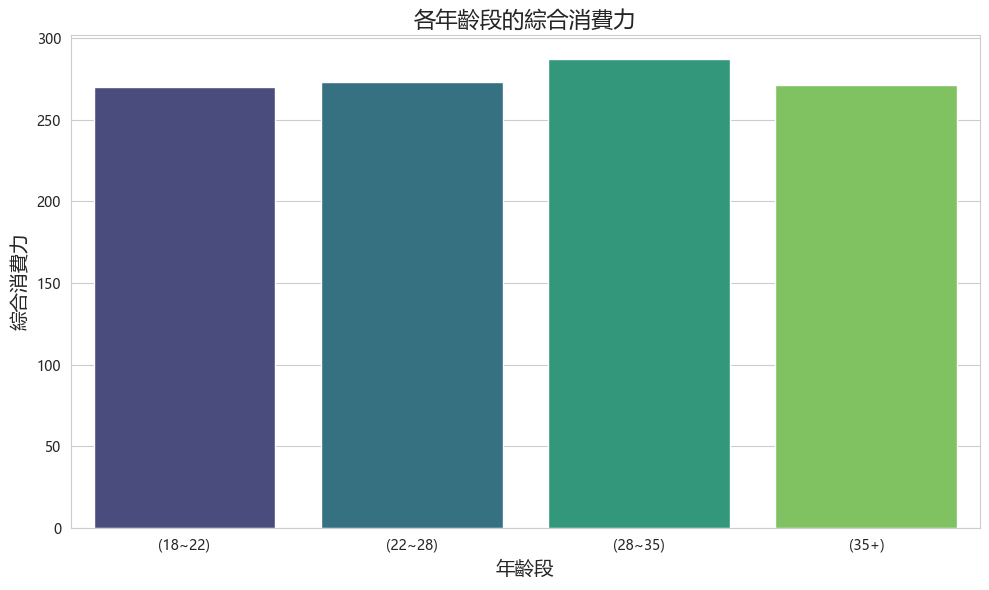

In [ ]:
# 繪製條形圖，顯示每個年齡段的消費力
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_stats.index, y=age_group_stats['consumption_power'], palette='viridis')

# 設置標題和軸標籤
plt.title("各年齡段的綜合消費力", fontsize=16)
plt.xlabel("年齡段", fontsize=14)
plt.ylabel("綜合消費力", fontsize=14)

# 顯示圖表
plt.tight_layout()
plt.show()

In [ ]:
data["Gender"].value_counts()

Gender
Female    452
Male      449
Name: count, dtype: int64

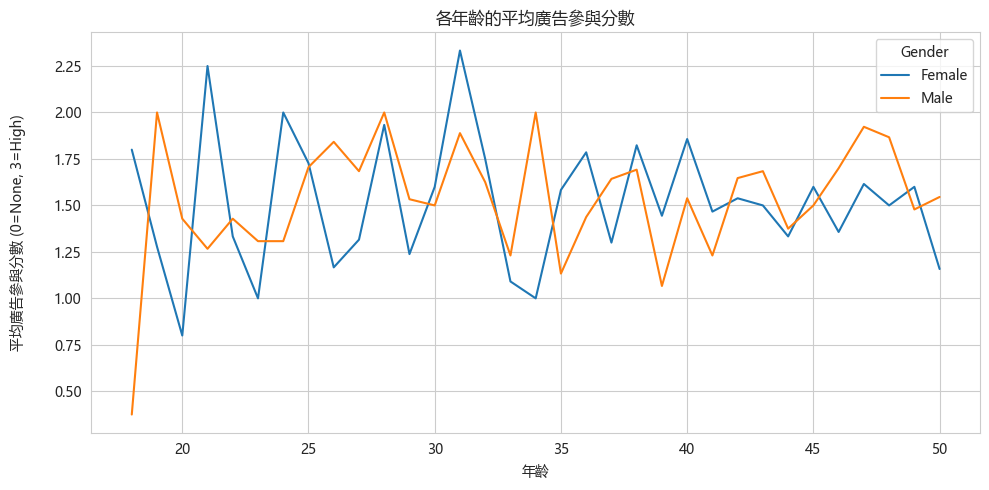

In [ ]:
# 計算每個年齡和性別的平均廣告參與分數
avg_ads_score_by_age_gender = data.groupby(['Age', 'Gender'])['Engagement_with_Ads_Score'].mean().reset_index()

# 繪製折線圖
plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_ads_score_by_age_gender, x='Age', y='Engagement_with_Ads_Score', hue='Gender')

# 設置標題和軸標籤
plt.title("各年齡的平均廣告參與分數")
plt.xlabel("年齡")
plt.ylabel('平均廣告參與分數 (0=None, 3=High)', rotation=90, labelpad=20)
plt.grid(True)
plt.tight_layout()
plt.show()


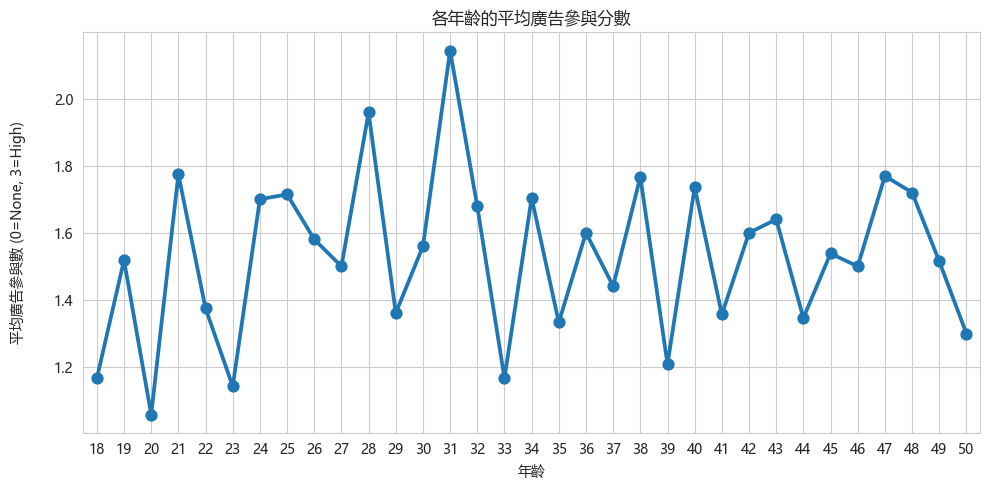

In [ ]:
# 計算每個年齡的平均廣告參與分數
avg_ads_score_by_age = data.groupby("Age")["Engagement_with_Ads_Score"].mean()
# 繪製折線圖
plt.figure(figsize=(10, 5))
sns.pointplot(x=avg_ads_score_by_age.index, y=avg_ads_score_by_age.values)
plt.title("各年齡的平均廣告參與分數")
plt.xlabel("年齡")
plt.ylabel('平均廣告參與數 (0=None, 3=High)', rotation=90, labelpad=20)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(data['Age'].max(), data['Age'].min())

In [ ]:
data.shape

(901, 31)

In [ ]:

for i in range(20,24):

    print("20歲數據量 : {}".format(data[data['Age'] == 20]['Engagement_with_Ads_Score'].count()))
age_20_data = data[data['Age'] == 20]
print("20歲數據量 : {}".format(age_20_data['Engagement_with_Ads_Score'].count()))

age_22_data = data[data['Age'] == 22]
print("22歲數據量 : {}".format(age_22_data['Engagement_with_Ads_Score'].count()))

20歲數據量 : 17
22歲數據量 : 16


Text(0.5, 0, '年齡')

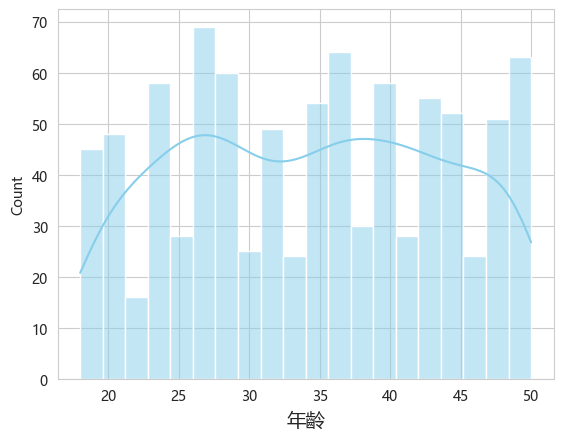

In [ ]:
sns.histplot(data, x='Age', kde=True, bins=20, color='skyblue')
plt.xlabel('年齡', fontsize=14)

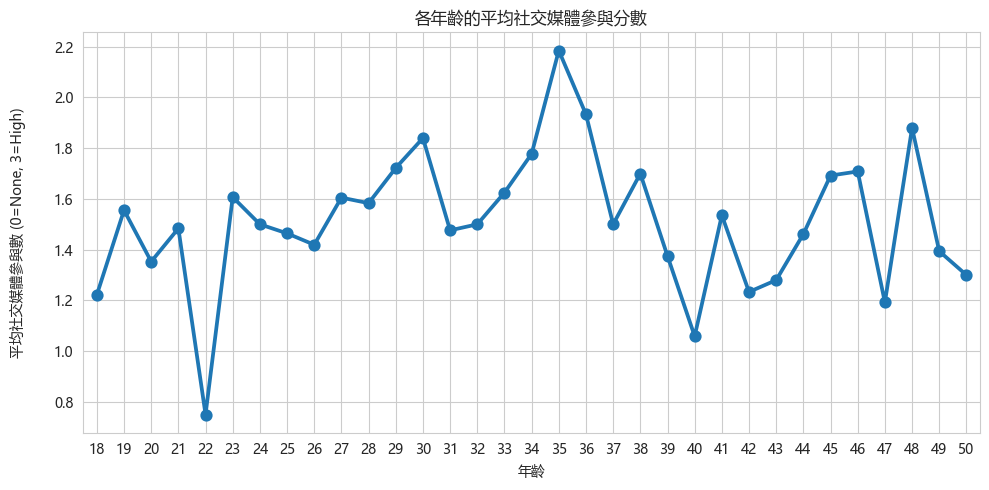

In [ ]:
# 計算每個年齡的平均社交媒體參與分數
social_Media_age = data.groupby("Age")["Social_Media_Score"].mean()
# 繪製折線圖
plt.figure(figsize=(10, 5))
sns.pointplot(x=social_Media_age.index, y=social_Media_age.values)
plt.title("各年齡的平均社交媒體參與分數")
plt.xlabel("年齡")
plt.ylabel('平均社交媒體參與數 (0=None, 3=High)', rotation=90, labelpad=20)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 移除缺失資料
#data = data.dropna(subset=['Engagement_with_Ads'])
#data = data.dropna(subset=['Engagement_with_Ads', 'Social_Media_Influence'])

In [ ]:
# 年齡在25~35歲"Baby Products"
age_25_to_35_baby_products = data[(data['Age'] >= 25) & (data['Age'] <= 35) & (data['Purchase_Category'] == 'Baby Products')]
# 計算購買渠道的偏好數量（Purchase_Channel）
purchase_channel_1 = age_25_to_35_baby_products['Purchase_Channel'].value_counts()
# 顯示結果
print("嬰兒用品:{}".format(purchase_channel_1))

# 年齡在25~35歲"Gardening & Outdoors"
age_25_to_35_Gardening = data[(data['Age'] >= 25) & (data['Age'] <= 35) & (data['Purchase_Category'] == 'Gardening & Outdoors')]
purchase_channel_2 = age_25_to_35_Gardening['Purchase_Channel'].value_counts()
print("園藝用品:{}".format(purchase_channel_2))

# 年齡在25~35歲"Food & Beverages"
age_25_to_35_Food = data[(data['Age'] >= 25) & (data['Age'] <= 35) & (data['Purchase_Category'] == 'Food & Beverages')]
purchase_channel_3 = age_25_to_35_Food['Purchase_Channel'].value_counts()
print("食物與飲品:{}".format(purchase_channel_3))
print("Total:\nOnline : 24\nMixed : 14\nIn-Store : 13")


嬰兒用品:Purchase_Channel
Online      7
Mixed       3
In-Store    3
Name: count, dtype: int64
園藝用品:Purchase_Channel
Mixed       8
In-Store    6
Online      5
Name: count, dtype: int64
食物與飲品:Purchase_Channel
Online      9
In-Store    4
Mixed       3
Name: count, dtype: int64
Total:
Online : 24
Mixed : 14
In-Store : 13


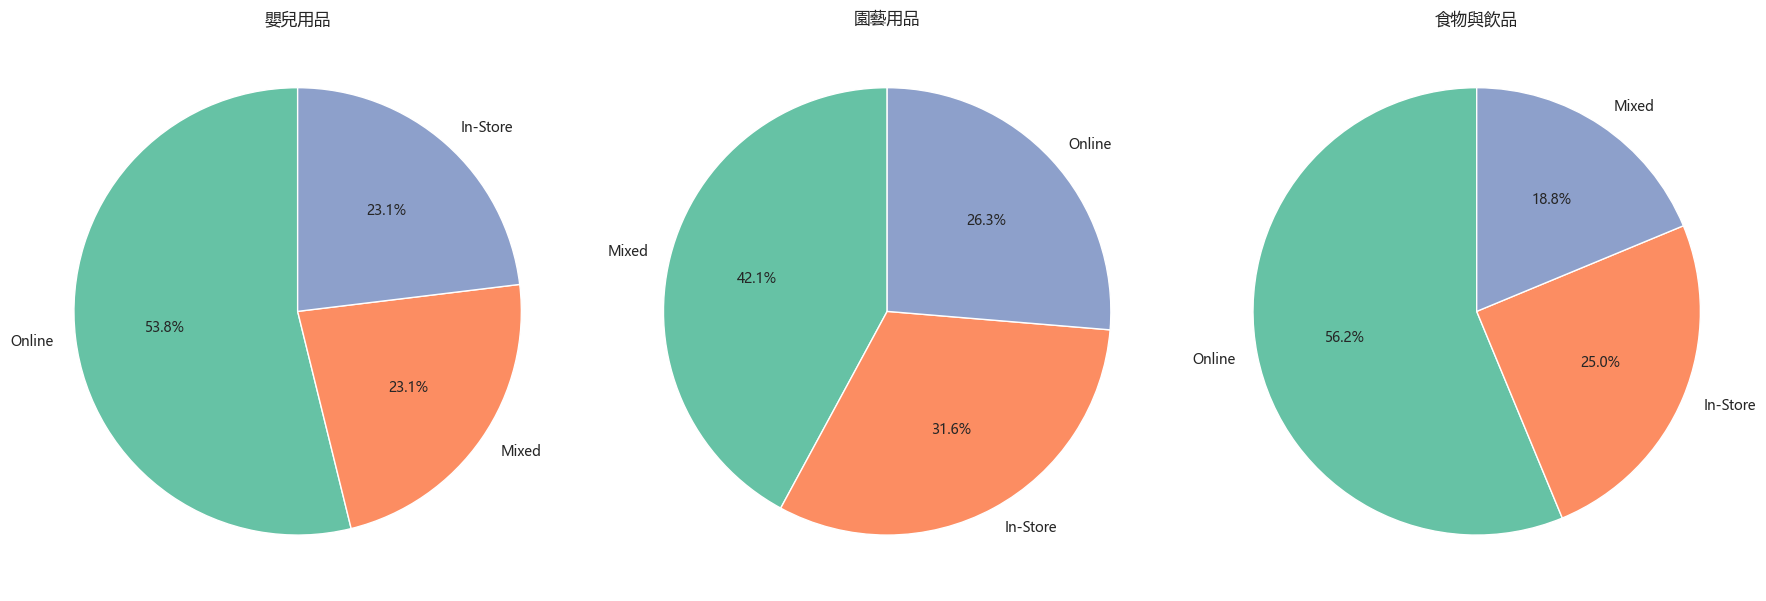

In [ ]:
# 設置子圖大小
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Baby Products
axes[0].pie(purchase_channel_1, labels=purchase_channel_1.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', n_colors=len(purchase_channel_1)))
axes[0].set_title('嬰兒用品')
# Gardening & Outdoors
axes[1].pie(purchase_channel_2, labels=purchase_channel_2.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', n_colors=len(purchase_channel_2)))
axes[1].set_title('園藝用品')

# Food & Beverages
axes[2].pie(purchase_channel_3, labels=purchase_channel_3.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', n_colors=len(purchase_channel_3)))
axes[2].set_title('食物與飲品')

# 顯示圖表
plt.tight_layout()
plt.show()

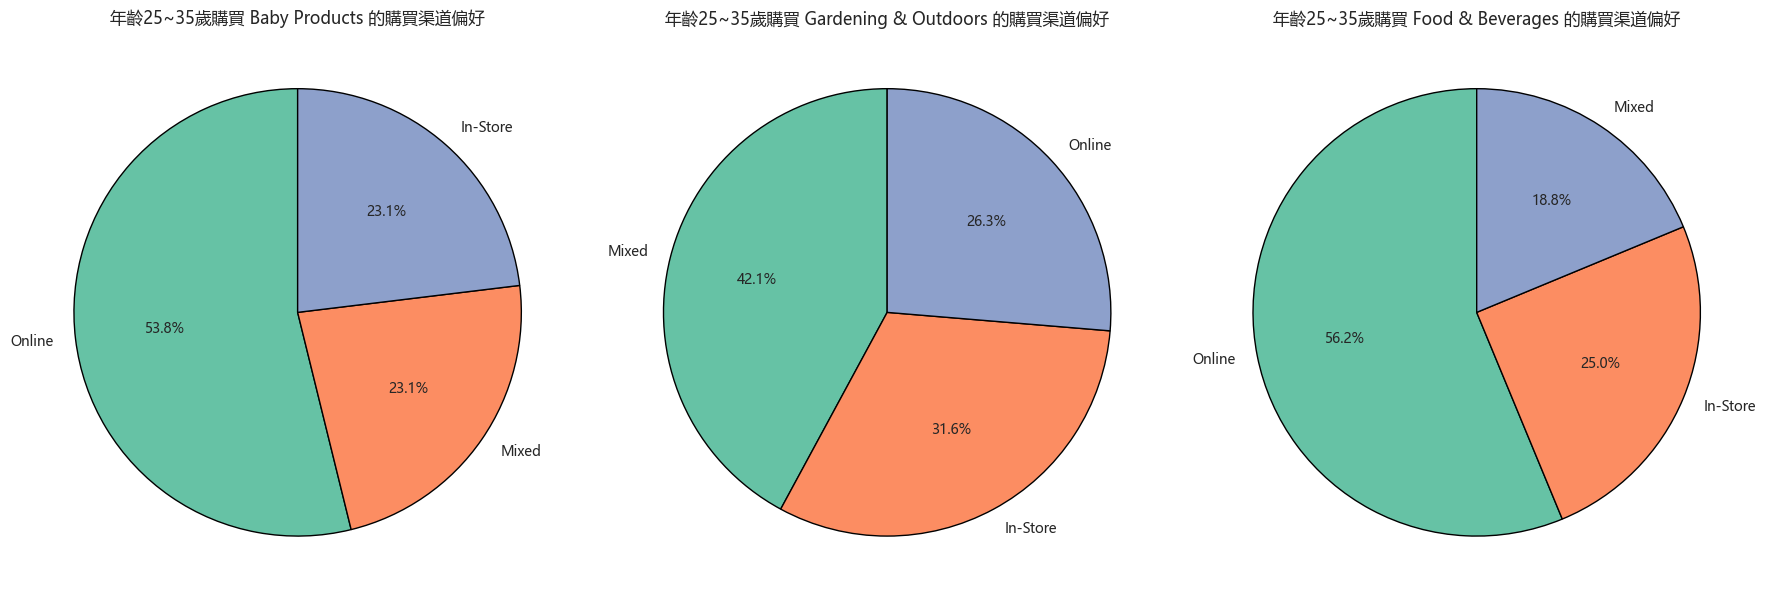

In [ ]:
# 設置子圖大小
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Baby Products 圓餅圖
axes[0].pie(purchase_channel_1, labels=purchase_channel_1.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', n_colors=len(purchase_channel_1)), wedgeprops={'edgecolor': 'black'})
axes[0].set_title('年齡25~35歲購買 Baby Products 的購買渠道偏好')

# Gardening & Outdoors 圓餅圖
axes[1].pie(purchase_channel_2, labels=purchase_channel_2.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', n_colors=len(purchase_channel_2)), wedgeprops={'edgecolor': 'black'})
axes[1].set_title('年齡25~35歲購買 Gardening & Outdoors 的購買渠道偏好')

# Food & Beverages 圓餅圖
axes[2].pie(purchase_channel_3, labels=purchase_channel_3.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', n_colors=len(purchase_channel_3)), wedgeprops={'edgecolor': 'black'})
axes[2].set_title('年齡25~35歲購買 Food & Beverages 的購買渠道偏好')

# 顯示圖表
plt.tight_layout()
plt.show()

In [ ]:
data["Purchase_Category"].unique()

array(['Gardening & Outdoors', 'Food & Beverages', 'Office Supplies',
       'Home Appliances', 'Furniture', 'Books', 'Mobile Accessories',
       'Sports & Outdoors', 'Luxury Goods', 'Animal Feed', 'Health Care',
       'Hotels', 'Packages)', 'Electronics', 'Software & Apps',
       'Baby Products', 'Toys & Games', 'Arts & Crafts',
       'Health Supplements', 'Groceries', 'Clothing',
       'Beauty & Personal Care', 'Travel & Leisure (Flights',
       'Jewelry & Accessories'], dtype=object)

<Figure size 1000x600 with 0 Axes>

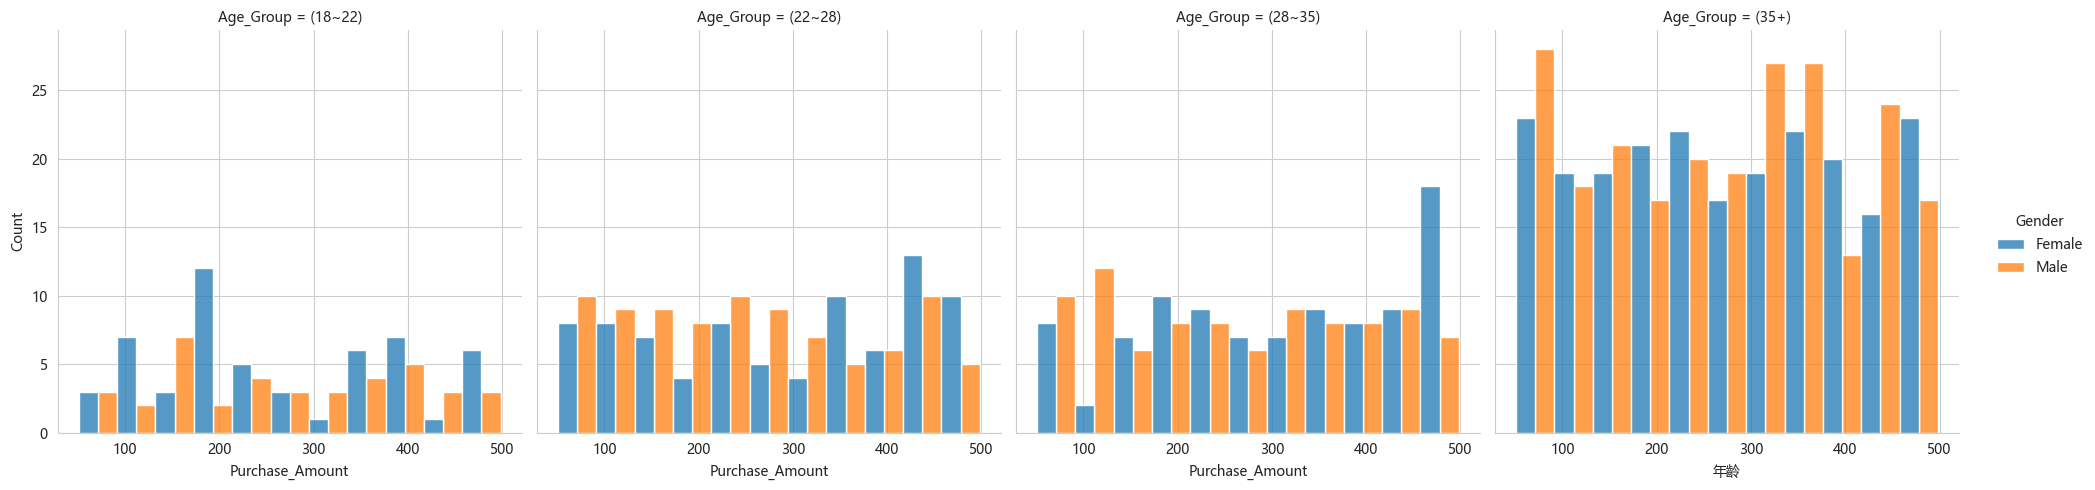

In [ ]:
plt.figure(figsize=(10, 6))
sns.displot(data, x="Purchase_Amount", col="Age_Group", hue="Gender", multiple="dodge")
#plt.title('Age vs Purchase Amount')
plt.xlabel('年齡')
plt.ylabel('購買金額')
plt.show()

In [ ]:
data.groupby(["Gender","Age_Group"])["Purchase_Category"].count().sort_values(ascending=True)

C:\Users\User\AppData\Local\Temp\ipykernel_19552\3516055065.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)


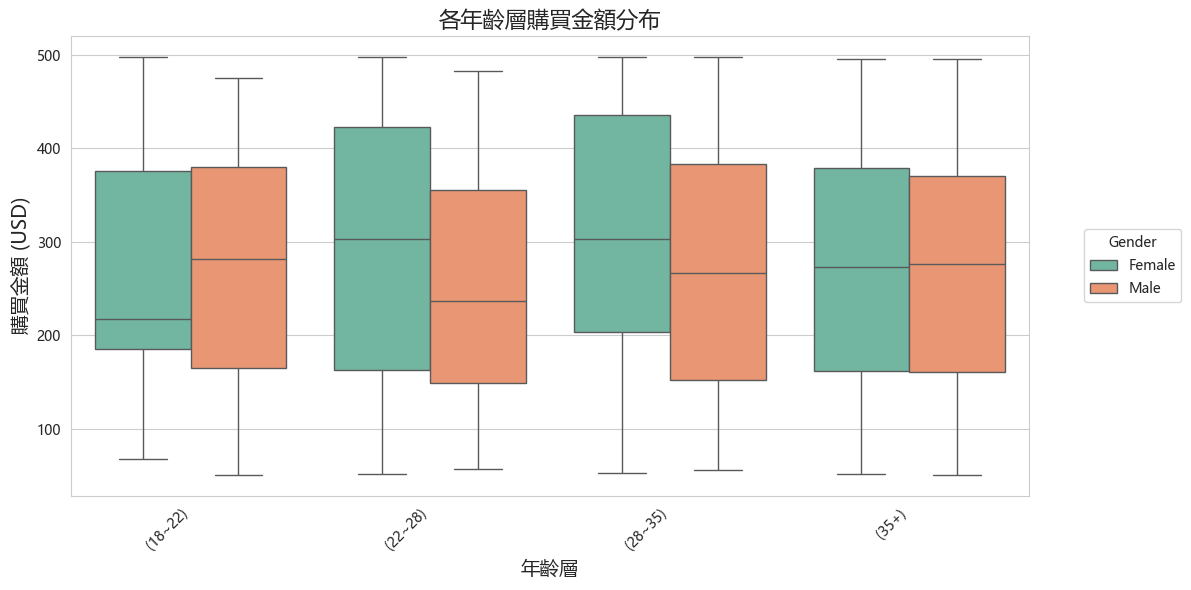

In [ ]:

#建立按性別劃分的年齡層與購買金額的boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data, x='Age_Group', y='Purchase_Amount', hue='Gender', palette='Set2')
plt.legend(title="Gender", bbox_to_anchor=(1.05, 0.5), loc='center left')
# Adjust axis and labels
plt.title('各年齡層購買金額分布', fontsize=16)
plt.xlabel('年齡層', fontsize=14)
plt.ylabel('購買金額 (USD)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to avoid overlapping labels

In [ ]:
# 將 'Travel & Leisure (Flights' 和 'Packages)' 合併為 'Travel & Leisure (Flights Packages)'
data.loc[:, 'Purchase_Category'] = data['Purchase_Category'].replace({'Travel & Leisure (Flights': 'Travel & Leisure',
                                                                       'Packages)': 'Travel & Leisure'})

In [ ]:
data['Purchase_Category'].unique()

Purchase_Category
Toys & Games                 7
Luxury Goods                 7
Packages)                    7
Food & Beverages             6
Groceries                    6
Animal Feed                  5
Office Supplies              5
Gardening & Outdoors         5
Home Appliances              5
Books                        5
Hotels                       5
Mobile Accessories           4
Health Care                  4
Furniture                    4
Sports & Outdoors            3
Beauty & Personal Care       3
Baby Products                3
Travel & Leisure (Flights    3
Software & Apps              2
Clothing                     2
Electronics                  2
Jewelry & Accessories        2
Health Supplements           2
Arts & Crafts                1
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_15352\3815101063.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purchase_preferences.index, y=purchase_preferences.values, palette='Set2')


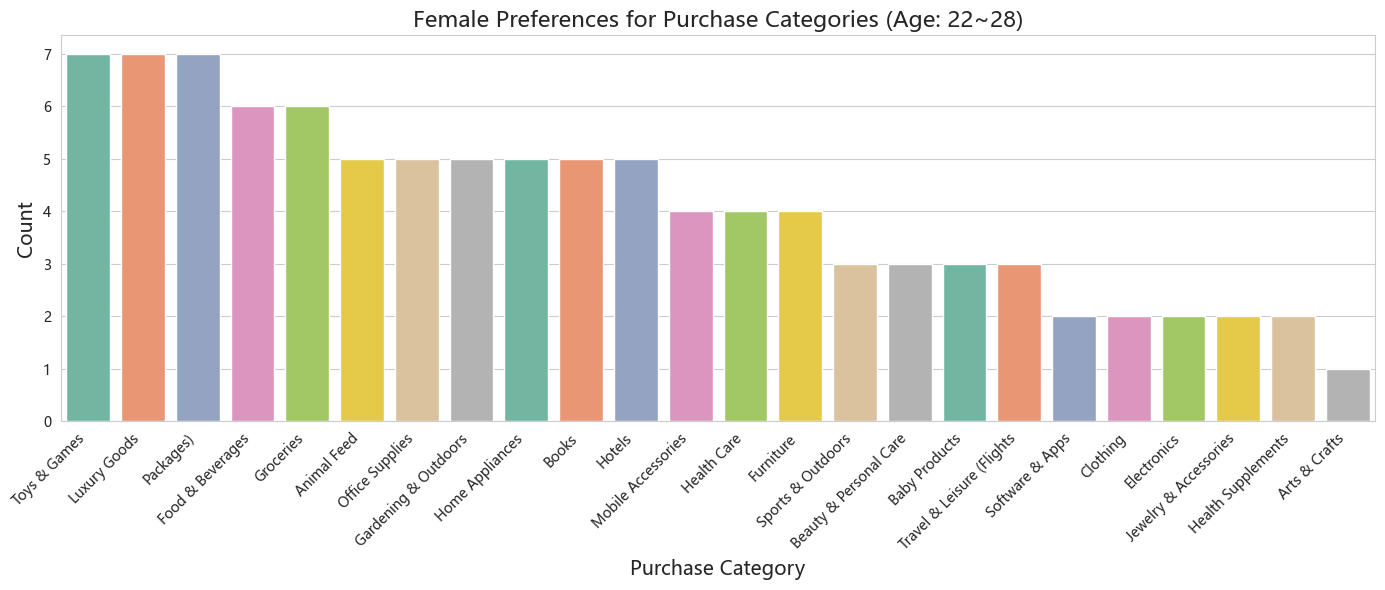

In [ ]:
# 將 'Flights' 和 'Packages' 合併為 'Travel & Leisure (Flights Packages)'
# 篩選出年齡為 22~28 歲的女性
filtered_data = data[(data['Age'] >= 22) & (data['Age'] <= 28) & (data['Gender'] == 'Female')]

# 計算每個購買類別的頻率
purchase_preferences = filtered_data['Purchase_Category'].value_counts()

# 查看篩選後的結果
print(purchase_preferences)

# 如果篩選後有數據，則繪製圖表
if not purchase_preferences.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(x=purchase_preferences.index, y=purchase_preferences.values, palette='Set2')

    # 設置標題和軸標籤
    plt.title('Female Preferences for Purchase Categories (Age: 22~28)', fontsize=16)
    plt.xlabel('Purchase Category', fontsize=14)
    plt.ylabel('Count', fontsize=14)

    # 旋轉 x 軸標籤，避免重疊
    plt.xticks(rotation=45, ha='right')

    # 顯示圖表
    plt.tight_layout()
    plt.show()
else:
    print("篩選後的數據為空，請檢查篩選條件")


In [ ]:
# 選取年齡範圍為 25 至 35 歲的資料
age_25_to_35 = data[(data['Age'] >= 25) & (data['Age'] <= 35)]
# 計算該年齡範圍內，每個購買類別的數量
purchase_category_count = age_25_to_35['Purchase_Category'].value_counts()
# 找出購買最多的前10個產品類別
print(purchase_category_count.head(10))

Purchase_Category
Gardening & Outdoors     19
Home Appliances          17
Animal Feed              17
Health Care              16
Food & Beverages         16
Jewelry & Accessories    16
Groceries                16
Electronics              16
Health Supplements       16
Hotels                   14
Name: count, dtype: int64


In [ ]:
# top_10_purchased_categories = purchase_category_count.head(10)
# # 顯示結果
# top_10_purchased_categories

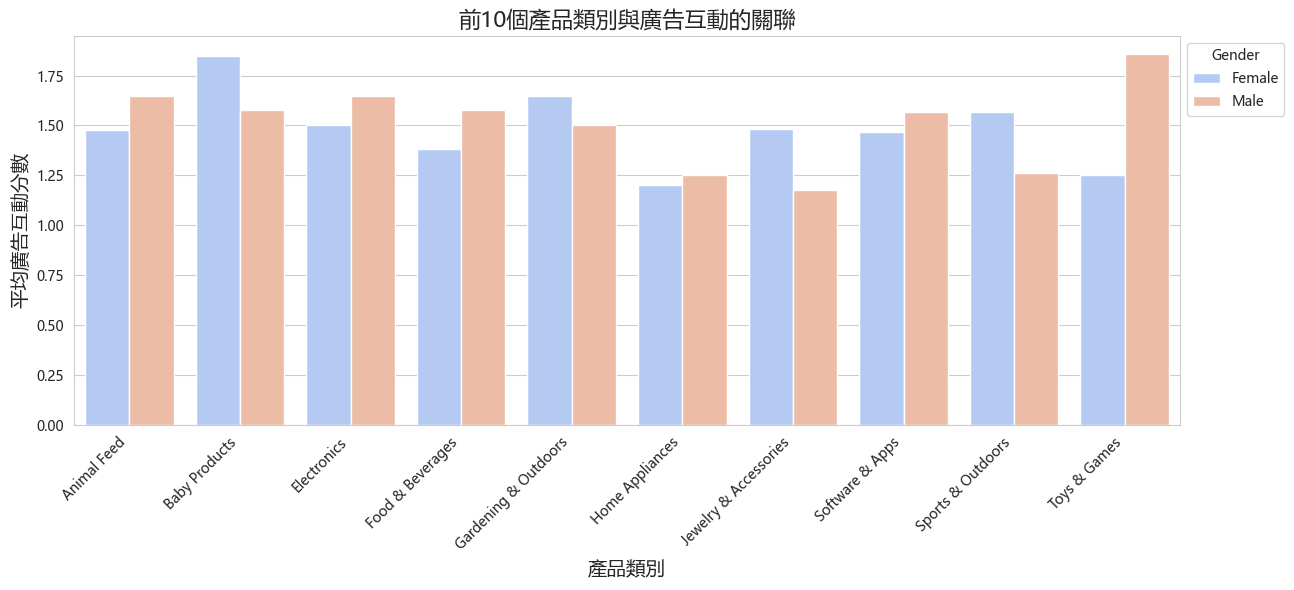

In [ ]:
# 計算每個產品類別在不同性別下的平均廣告互動分數
top_10_categories = data['Purchase_Category'].value_counts().head(10).index
top_10_data = data[data['Purchase_Category'].isin(top_10_categories)]
avg_eng__category = top_10_data.groupby(['Purchase_Category', 'Gender'])['Engagement_with_Ads_Score'].mean().reset_index()

# 繪製條形圖，按性別區分
plt.figure(figsize=(12, 6))
sns.barplot(x='Purchase_Category', y='Engagement_with_Ads_Score', hue='Gender', data=avg_eng__category, palette='coolwarm')

# 設置標題和軸標籤
plt.title('前10個產品類別與廣告互動的關聯', fontsize=16)
plt.xlabel('產品類別', fontsize=14)
plt.ylabel('平均廣告互動分數', fontsize=14)
plt.xticks(rotation=45, ha='right')  # 旋轉x軸標籤，避免重疊
plt.tight_layout()
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")

# 顯示圖表
plt.show()


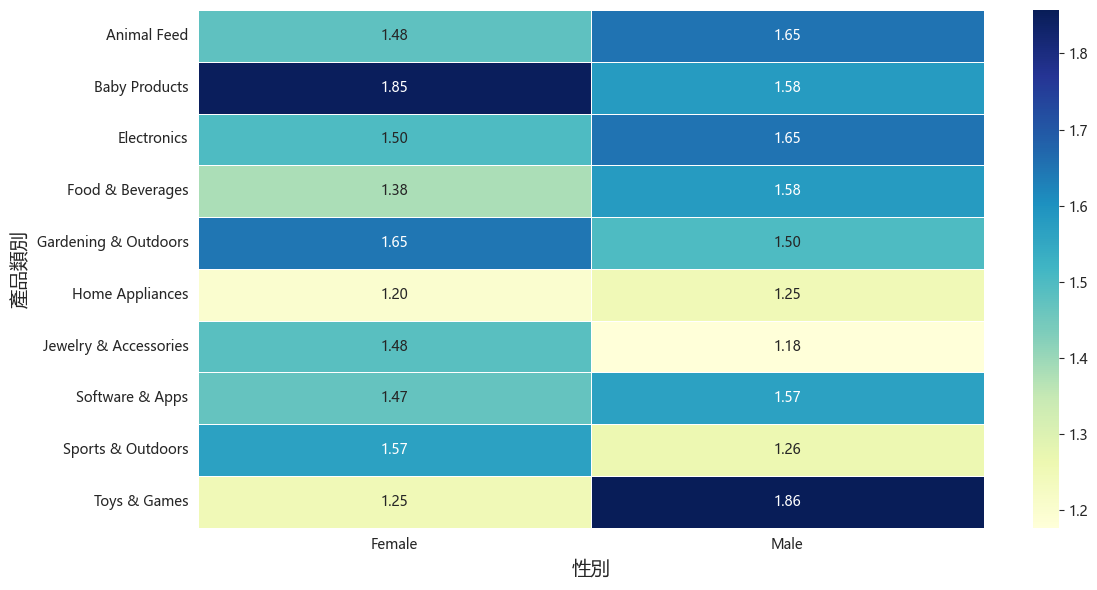

In [ ]:
# 計算每個購買類別和性別組合的平均廣告互動分數
avg_engagement_matrix = avg_eng__category.pivot_table(index='Purchase_Category', columns='Gender', values='Engagement_with_Ads_Score', aggfunc='mean')

# 繪製熱力圖
plt.figure(figsize=(12, 6))
sns.heatmap(avg_engagement_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)

# 設置標題和軸標籤
#plt.title('前10個產品類別與廣告互動的熱力圖', fontsize=16)
plt.xlabel('性別', fontsize=14)
plt.ylabel('產品類別', fontsize=14)

# 顯示圖表
plt.tight_layout()
plt.show()


In [ ]:
print(data['Social_Media_Score'].dtype)

int64


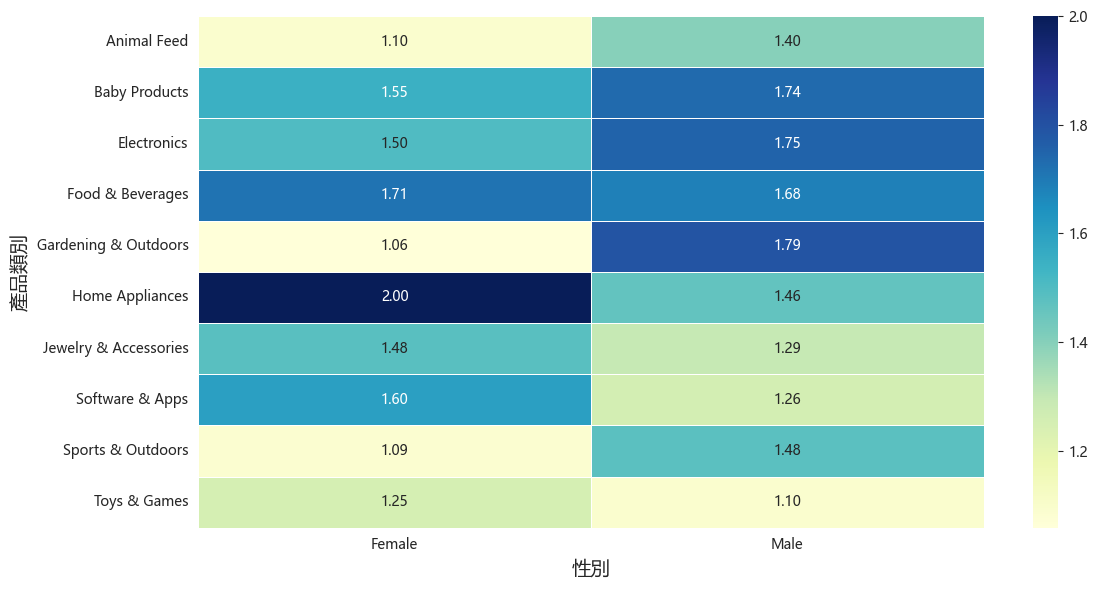

In [ ]:
# 計算每個購買類別和性別組合的平均廣告互動分數
avg_eng__category2 = top_10_data.groupby(['Purchase_Category', 'Gender'])['Social_Media_Score'].mean().reset_index()
avg_engagement_matrix = avg_eng__category2.pivot_table(index='Purchase_Category', columns='Gender', values='Social_Media_Score', aggfunc='mean')

# 繪製熱力圖
plt.figure(figsize=(12, 6))
sns.heatmap(avg_engagement_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)

# 設置標題和軸標籤
#plt.title('前10個產品類別與廣告互動的熱力圖', fontsize=16)
plt.xlabel('性別', fontsize=14)
plt.ylabel('產品類別', fontsize=14)

# 顯示圖表
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_15352\3301411321.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_eng__category.index, y=avg_eng__category.values, palette='coolwarm')
C:\Users\User\AppData\Local\Temp\ipykernel_15352\3301411321.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")


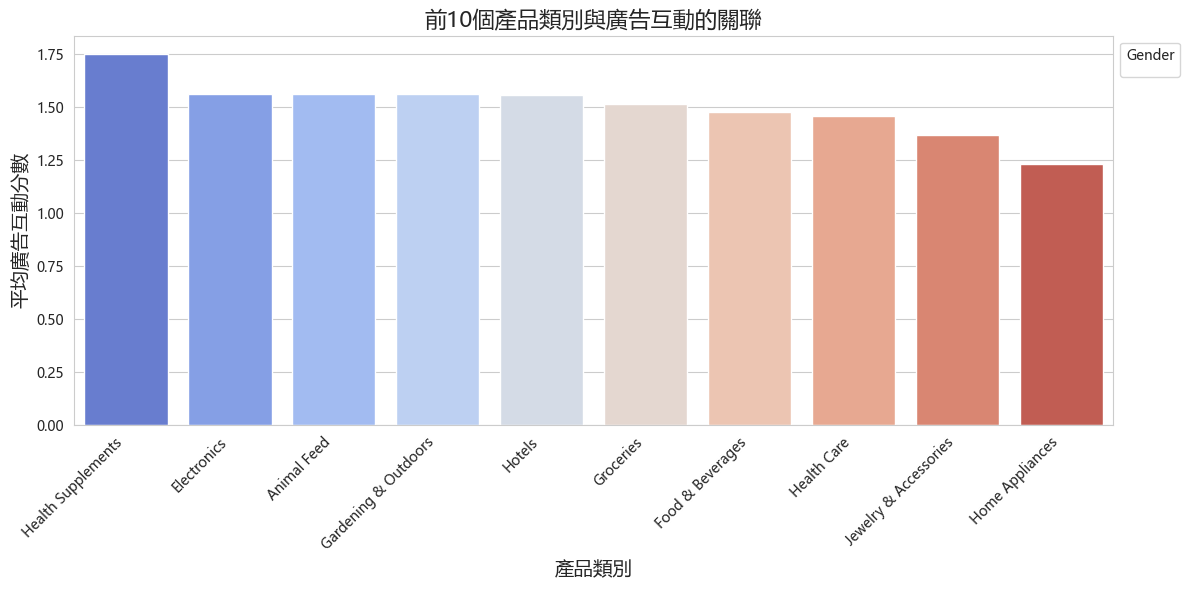

In [ ]:
# 選取前10個產品類別
top_10_categories = purchase_category_count.head(10).index

# 篩選出這些產品類別的資料
top_10_data = data[data['Purchase_Category'].isin(top_10_categories)]

# 計算每個產品類別的平均廣告互動分數
avg_eng__category = top_10_data.groupby('Purchase_Category')['Engagement_with_Ads_Score'].mean().sort_values(ascending=False)

# 可視化產品類別與廣告互動的關聯
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_eng__category.index, y=avg_eng__category.values, palette='coolwarm')

# 設置標題和軸標籤
plt.title('前10個產品類別與廣告互動的關聯', fontsize=16)
plt.xlabel('產品類別', fontsize=14)
plt.ylabel('平均廣告互動分數', fontsize=14)
plt.xticks(rotation=45, ha='right')  # 旋轉x軸標籤，避免重疊

plt.tight_layout()
# 顯示圖表
plt.show()

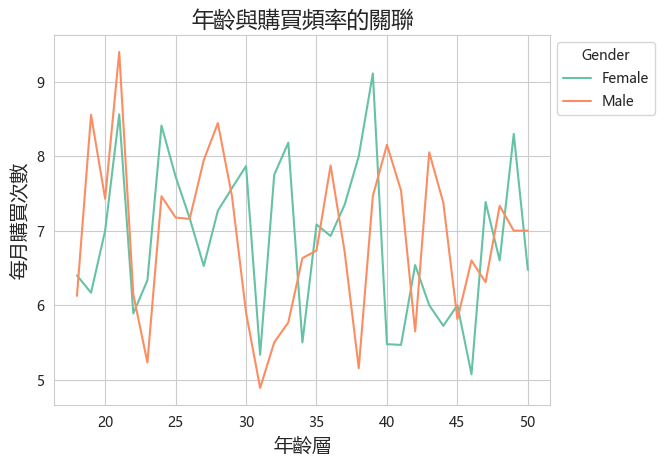

In [ ]:
# Frequency_of_Purchase購買頻率，Age_Group年齡範圍，Gender是性別
#plt.figure(figsize=(12, 6))

# 使用箱型圖，根據年齡層和購買頻率繪圖，並根據性別分類
#sns.boxplot(data, x='Age_Group', y='Frequency_of_Purchase', hue='Gender', palette='Set2')
sns.lineplot(data, x='Age', y='Frequency_of_Purchase', hue='Gender', palette='Set2', errorbar=None)
# 設置標題和軸標籤
plt.title('年齡與購買頻率的關聯', fontsize=16)
plt.xlabel('年齡層', fontsize=14)
plt.ylabel('每月購買次數', fontsize=14)
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")

# 顯示圖表
plt.show()


In [ ]:
# 設置FacetGrid
g = sns.FacetGrid(data, col='Purchase_Amount', hue='Gender', palette='Set2')

# 在每個子圖上繪製lineplot
g.map(sns.lineplot, 'Age', 'Frequency_of_Purchase', errorbar=None)

# 設置標題和軸標籤
g.set_axis_labels('年齡層', '每月購買次數')
g.set_titles('購買金額: {col_name}', fontsize=16)

# 顯示圖例
g.add_legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")

# 顯示圖表
plt.show()


In [ ]:
gender_purchase_crosstab = pd.crosstab(data['Purchase_Category'], data['Gender'], normalize='index')

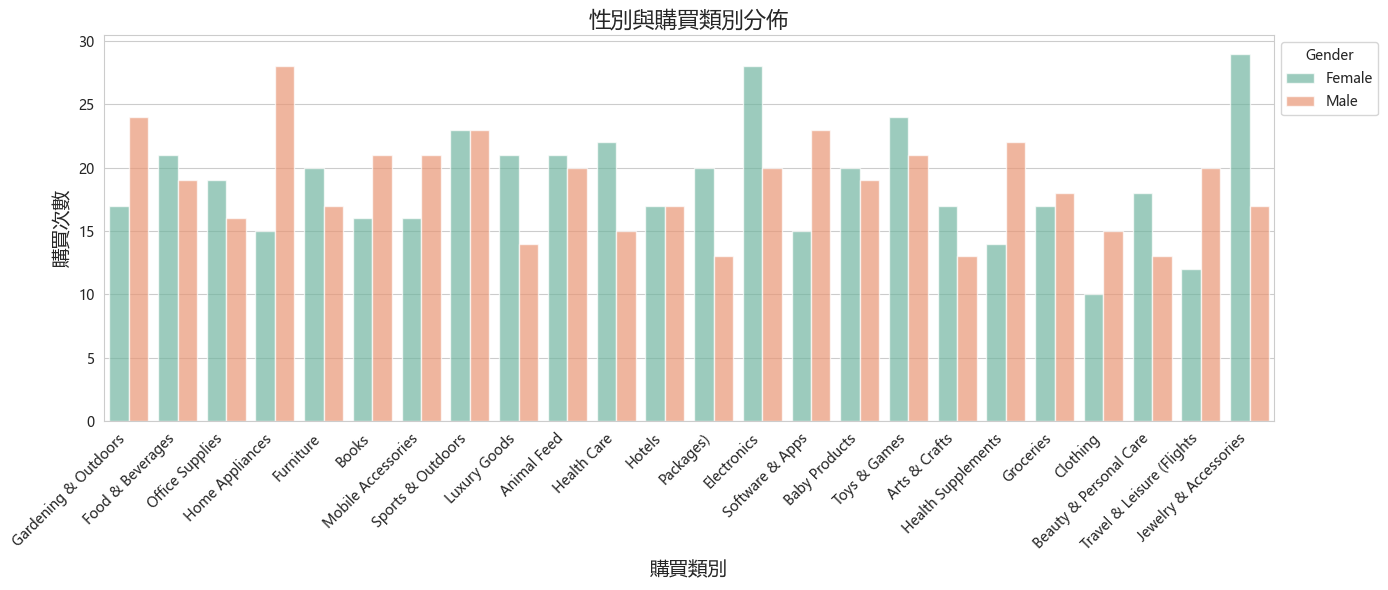

In [ ]:
plt.figure(figsize=(14, 6))

# 使用 countplot 繪製性別和購買類別之間的分佈情況
ax = sns.countplot(data, x='Purchase_Category', hue='Gender', palette='Set2',alpha=0.7)
# 設置標題和軸標籤
plt.title('性別與購買類別分佈', fontsize=16)
plt.xlabel('購買類別', fontsize=14)
plt.ylabel('購買次數', fontsize=14)

# 旋轉 x 軸標籤，避免重疊
plt.xticks(rotation=45, ha='right')  # 旋轉 45 度並調整標籤對齊
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")

# 使用 tight_layout() 自動調整圖表間距，避免標籤重疊
plt.tight_layout()

# 顯示圖表
plt.show()

In [ ]:
# 計算每個性別和購買類別的數量
gender_purchase_count = data.groupby(['Gender', 'Purchase_Category']).size().reset_index(name='Count')

# 找出 Male 和 Female 的前三高的購買類別
top_male = gender_purchase_count[gender_purchase_count['Gender'] == 'Male'].sort_values(by='Count', ascending=False).head(3)
top_female = gender_purchase_count[gender_purchase_count['Gender'] == 'Female'].sort_values(by='Count', ascending=False).head(3)

# 顯示結果
print("男性購買類別Top3:")
print(top_male[['Purchase_Category', 'Count']])
print("\n")
print("女性男性購買類別:")
print(top_female[['Purchase_Category', 'Count']])


男性購買類別Top3:
       Purchase_Category  Count
37       Home Appliances     28
33  Gardening & Outdoors     24
45     Sports & Outdoors     23


女性男性購買類別:
        Purchase_Category  Count
15  Jewelry & Accessories     29
6             Electronics     28
22           Toys & Games     24


In [ ]:

plt.figure(figsize=(14, 6))

# 使用 countplot 繪製性別和購買類別之間的分佈情況
sns.displot(x='Purchase_Category', hue='Gender', data=data, palette='Set2', multiple="dodge")

# 設置標題和軸標籤
plt.title('Male and Female Preferences by Product Category', fontsize=16)
plt.xlabel('Purchase Category', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")

# 旋轉 x 軸標籤
plt.xticks(rotation=45, ha='right')  # 旋轉 45 度並調整標籤對齊

# 使用 tight_layout() 自動調整圖表間距，避免標籤重疊
plt.tight_layout()

# 顯示圖表
plt.show()



In [ ]:

# 計算每個性別在每個產品類別中的購買次數
gender_purchase_crosstab = pd.crosstab(data['Purchase_Category'], data['Gender'])

# 重設索引，使其適用於seaborn
gender_purchase_crosstab = gender_purchase_crosstab.reset_index()

# 將數據轉換為長格式，方便繪製堆疊條形圖
gender_purchase_long = gender_purchase_crosstab.melt(id_vars='Purchase_Category',
                                                     value_vars=gender_purchase_crosstab.columns[1:],
                                                     var_name='Gender',
                                                     value_name='Count')

# 繪製堆疊條形圖
plt.figure(figsize=(12, 6))
sns.barplot(data=gender_purchase_long, x='Purchase_Category', y='Count', hue='Gender')

# 設置標題和軸標籤
plt.title('Male and Female Preferences by Product Category (Stacked)', fontsize=16)
plt.xlabel('Purchase Category', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")
plt.xticks(rotation=45, ha='right')

# 顯示圖表
plt.tight_layout()
plt.show()


In [ ]:
corr = data[['Purchase_Category', 'Engagement_with_Ads', 'Gender']].corr()

In [ ]:
# 檢查篩選條件後的資料
print(data[data['Engagement_with_Ads'] == 'None'].shape)  # 檢查 'None' 序列的行數

In [ ]:
# 篩選出 22~35 歲的女性
filtered_data = data[(data['Age'] >= 22) & (data['Age'] <= 35) & (data['Gender'] == 'Female')]

# 計算每個 Social Media Influence 層級的數量
social_media_influence_counts = filtered_data['Social_Media_Influence'].value_counts()

# 計算每個層級的比例
social_media_influence_percentage = filtered_data['Social_Media_Influence'].value_counts(normalize=True) * 100
print(social_media_influence_counts)
print(social_media_influence_percentage)

# 繪製條形圖，顯示每個層級的影響力分佈
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x='Social_Media_Influence', palette='Set2')

# 設置標題和軸標籤
plt.title('Social Media Influence on Female (Age: 22~35)', fontsize=16)
plt.xlabel('Social Media Influence', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 顯示圖表
plt.tight_layout()
plt.show()

# 根據比例來確定哪個層級的影響較大
max_influence_level = social_media_influence_percentage.idxmax()
max_influence_percentage = social_media_influence_percentage.max()

print(f"The Social Media Influence level that affects females aged 22-35 the most is {max_influence_level}, with {max_influence_percentage:.2f}% of the population.")



In [ ]:
sns.displot(data, x="Age", hue='Social_Media_Score', col="Gender", multiple="dodge", kde=True)

In [ ]:
data.groupby("Gender")["Social_Media_Score"]

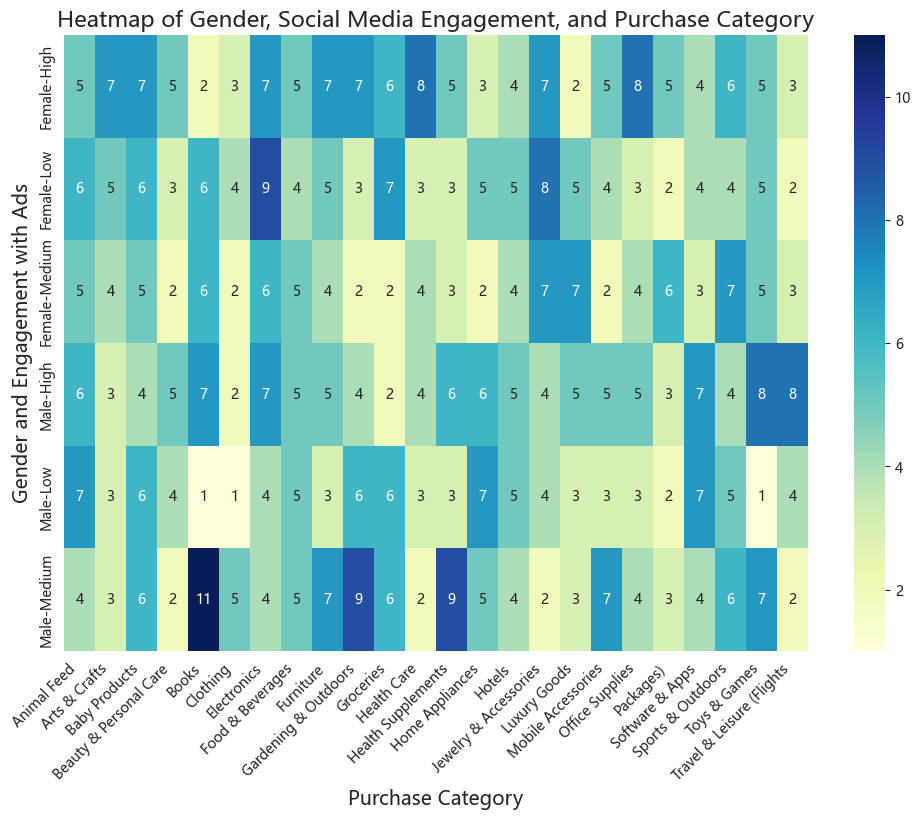

In [ ]:
# 計算性別、廣告互動與購買類別的交叉表
engagement_category_gender_crosstab = pd.crosstab([data['Gender'], data['Engagement_with_Ads']], data['Purchase_Category'])

# 繪製熱圖
plt.figure(figsize=(12, 8))
sns.heatmap(engagement_category_gender_crosstab, annot=True, cmap='YlGnBu', fmt='d', cbar=True)

# 設置標題
plt.title('Heatmap of Gender, Social Media Engagement, and Purchase Category', fontsize=16)
plt.xlabel('Purchase Category', fontsize=14)
plt.ylabel('Gender and Engagement with Ads', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# 將數據轉換為長格式，適用於 seaborn
gender_purchase_long = gender_purchase_crosstab.reset_index().melt(id_vars='Purchase_Category',
                                                                  value_vars=gender_purchase_crosstab.columns,
                                                                  var_name='Gender',
                                                                  value_name='Count')

# 繪製堆疊條形圖
plt.figure(figsize=(12, 6))
sns.barplot(x='Purchase_Category', y='Count', hue='Gender', data=gender_purchase_long, palette='Set2')

# 設置標題和軸標籤
plt.title('Male and Female Preferences by Product Category', fontsize=16)
plt.xlabel('Purchase Category', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 旋轉 x 軸標籤，避免重疊
plt.xticks(rotation=45, ha='right')

# 顯示圖表
plt.tight_layout()
plt.show()


NameError: name 'gender_purchase_crosstab' is not defined

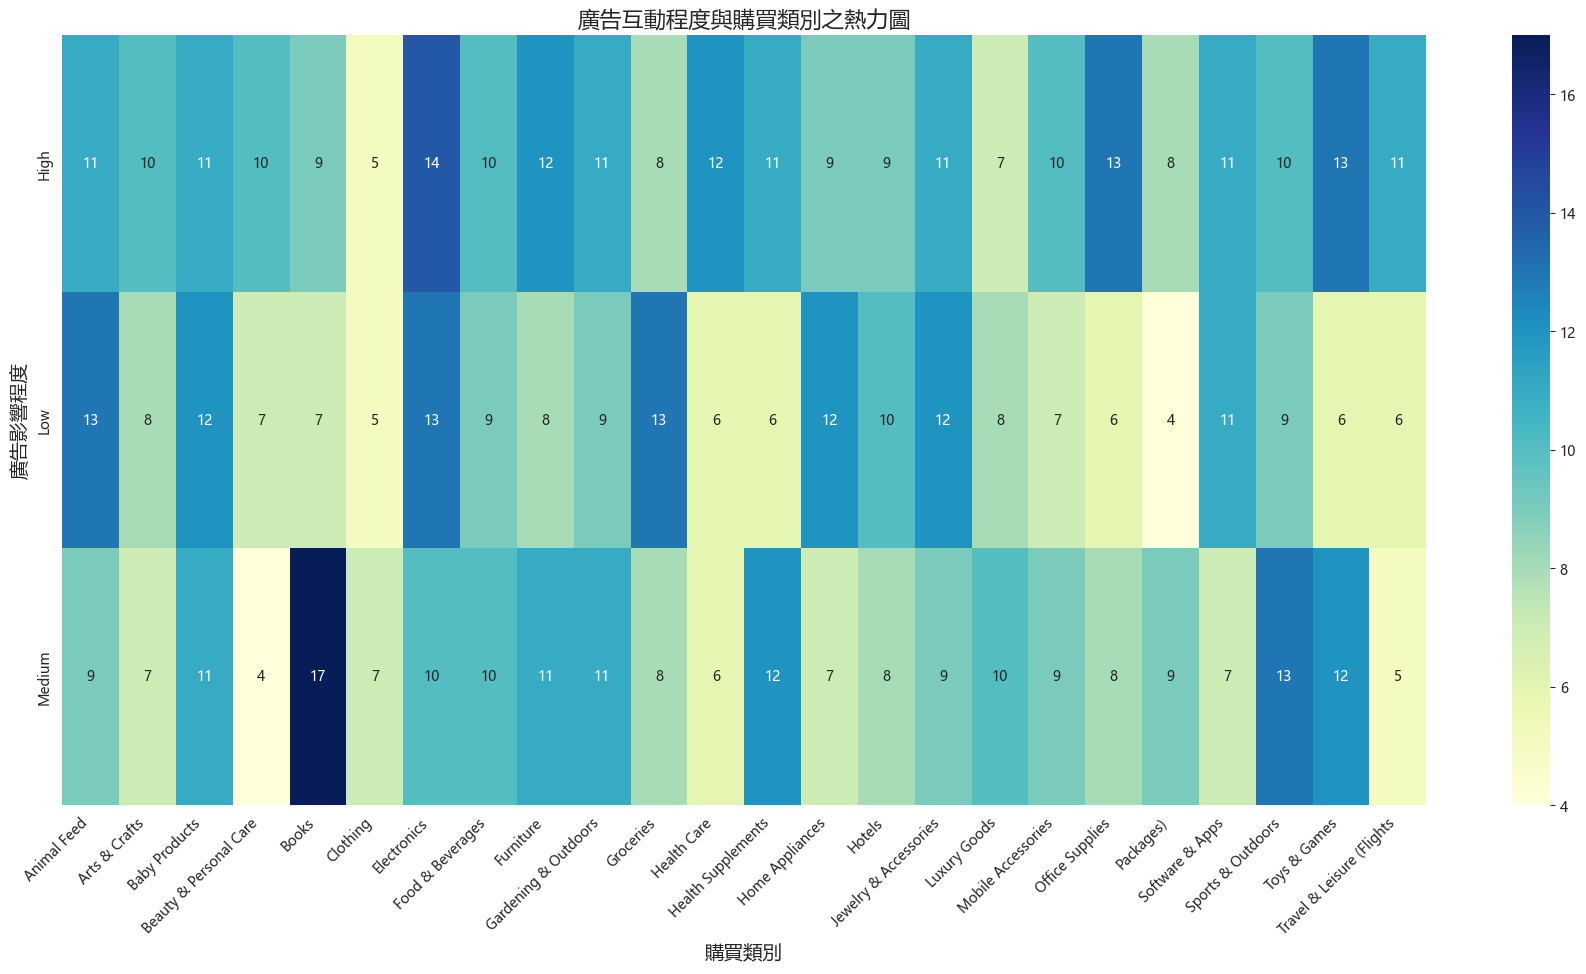

In [ ]:
# 計算廣告互動程度與購買類別之間的交叉表
engagement_crosstab = pd.crosstab(data['Engagement_with_Ads'], data['Purchase_Category'])

# 繪製熱圖
plt.figure(figsize=(22, 10))
sns.heatmap(engagement_crosstab, annot=True, cmap='YlGnBu', fmt='d', cbar=True)

# 設置標題
plt.title('廣告互動程度與購買類別之熱力圖', fontsize=16)
plt.xlabel('購買類別', fontsize=14)
plt.ylabel('廣告影響程度', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()


<Figure size 2000x1000 with 0 Axes>

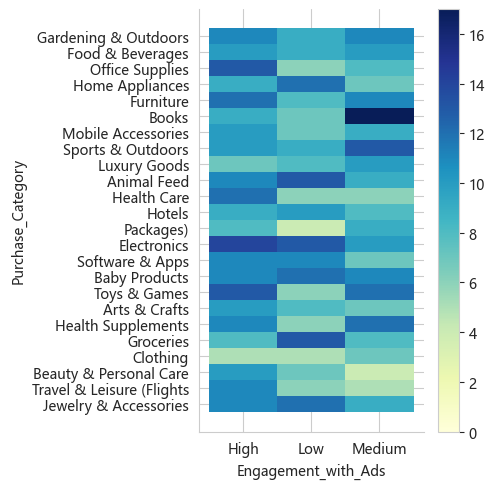

In [ ]:
plt.figure(figsize=(20, 10))
sns.displot(data, x="Engagement_with_Ads", y="Purchase_Category",cmap='YlGnBu', binwidth=(2, .5), cbar=True)

In [ ]:
#One way ANOVA
#H0:教育程度與購買金額無顯著關係vs. H1:教育程度與購買金額有顯著關係，若p-value<0.05，則可以拒絕H0，認為教育程度與購買金額有顯著的統計關聯。
from scipy.stats import f_oneway

# 假設 'Education_Level' 是分類變數，'Purchase_Amount' 是連續變數
# 計算每個教育程度對應的購買金額數據
grouped_data = [data[data['Education_Level'] == level]['Purchase_Amount'] for level in data['Education_Level'].unique()]

# 進行 ANOVA 檢定
f_stat, p_value = f_oneway(*grouped_data)

# 顯示結果
print("F-statistic: ".format(f_stat))
print("P-value: ".format(p_value))

F-statistic: 
P-value: 


In [ ]:
education_purchase_mean = data.groupby('Education_Level')['Purchase_Amount'].mean()
print(education_purchase_mean)

Education_Level
Bachelor's     283.928251
High School    271.123209
Master's       269.475728
Name: Purchase_Amount, dtype: float64


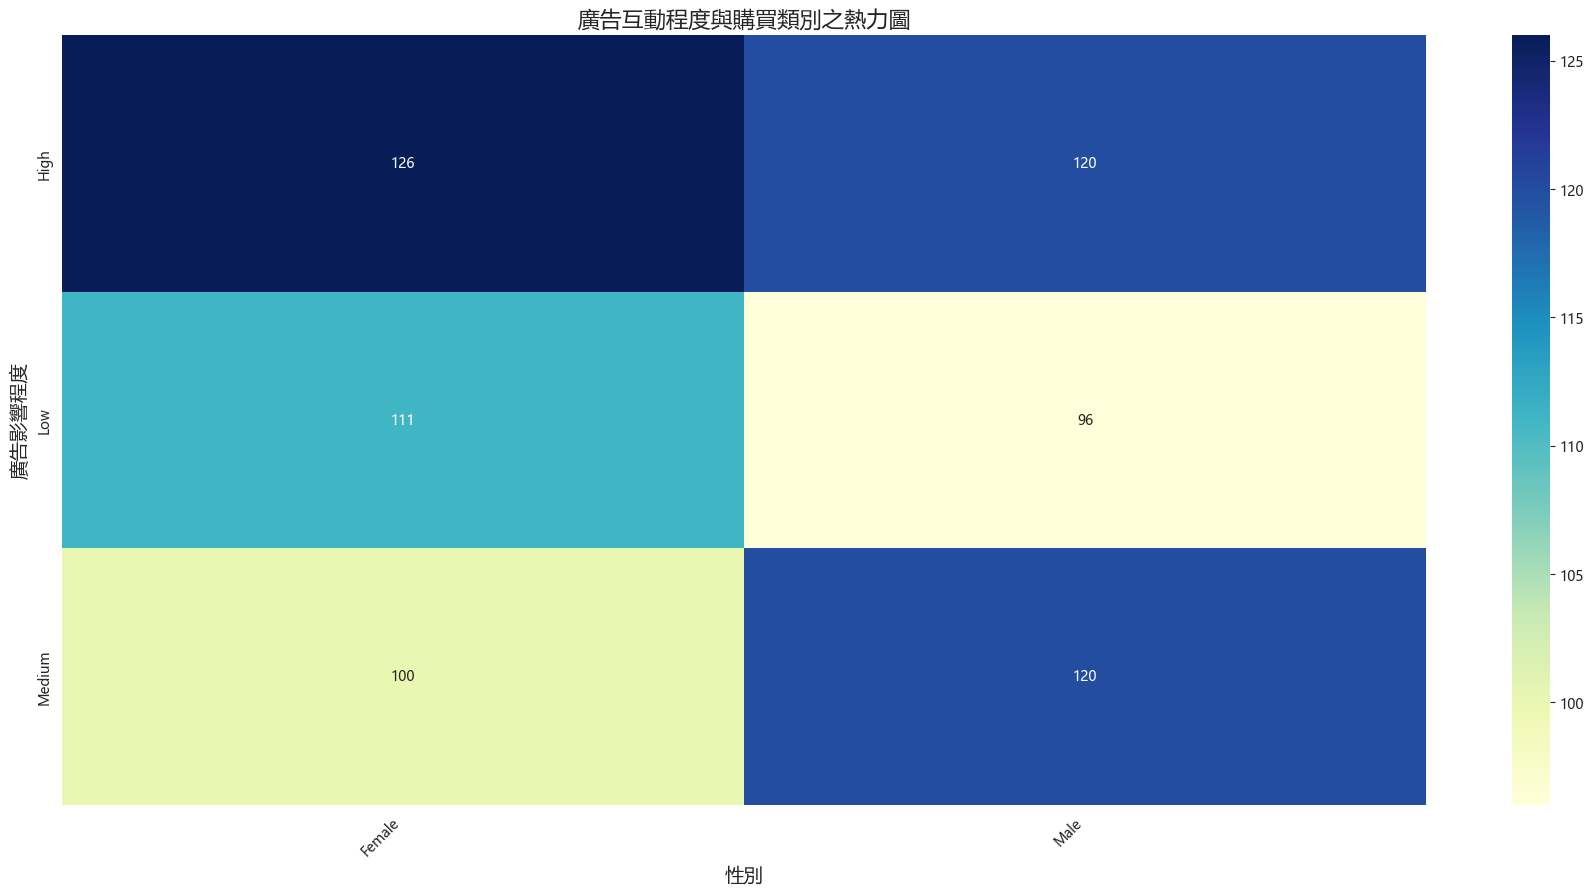

In [ ]:
# 計算廣告互動程度與購買類別之間的交叉表
engagement_crosstab = pd.crosstab(data['Engagement_with_Ads'], data['Gender'])

# 繪製熱圖
plt.figure(figsize=(22, 10))
sns.heatmap(engagement_crosstab, annot=True, cmap='YlGnBu', fmt='d', cbar=True)

# 設置標題
plt.title('廣告互動程度與購買類別之熱力圖', fontsize=16)
plt.xlabel('性別', fontsize=14)
plt.ylabel('廣告影響程度', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()


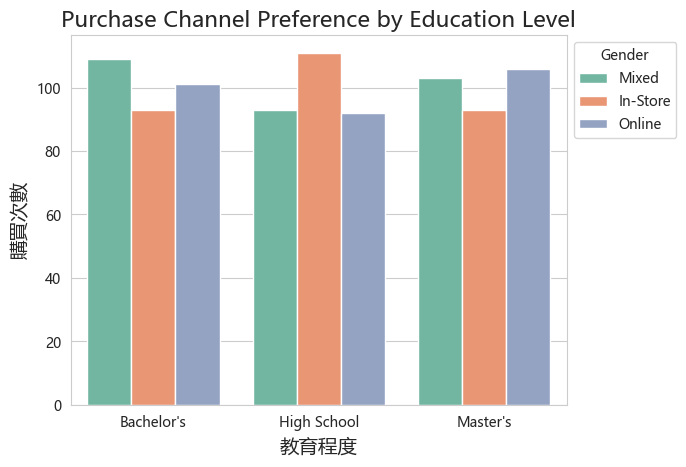

In [ ]:
#plt.figure(figsize=(12, 6))

# 使用 countplot 繪製教育程度和購買渠道的分佈情況
sns.countplot(data, x='Education_Level', hue='Purchase_Channel', palette='Set2')
# 設置標題和軸標籤
plt.title('Purchase Channel Preference by Education Level', fontsize=16)
plt.xlabel('教育程度', fontsize=14)
plt.ylabel('購買次數', fontsize=14)
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

In [ ]:
# 使用 countplot 繪製教育程度和購買渠道的分佈情況
sns.countplot(data, x='Education_Level', hue='Customer_Satisfaction', palette='Set2')
# 設置標題和軸標籤
plt.title('Purchase Channel Preference by Education Level', fontsize=16)
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

In [ ]:
sns.boxplot(data, x='Purchase_Intent', hue='Age', palette='Set2')
#sns.boxplot(data, y="Age", x="Purchase_Intent", hue="Gender")
plt.title('年齡與購買意願關係', fontsize=14)
plt.legend(title="Age_Group", bbox_to_anchor=(1, 1), loc="upper left")

In [ ]:
sns.displot(data, x="Purchase_Intent", hue="Age_Group")

In [ ]:
data["Purchase_Category"].unique()

In [ ]:
data.head()

In [ ]:
age_score_distribution = df_sorted.groupby("Age")["Engagement_with_Ads_Score"].value_counts(normalize=True).unstack().fillna(0)
# 繪製廣告參與度分數比例的熱力圖
plt.figure(figsize=(12, 8))
sns.heatmap(age_score_distribution, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Engagement with Ads Score Distribution by Age")
plt.xlabel("Engagement Score (0=None, 3=High)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [ ]:
# 計算所有年齡層中，各 Engagement Score 的總比例
total_distribution = age_score_long.groupby("Engagement_Score")["Proportion"].sum()

# 畫圓餅圖
plt.figure(figsize=(6, 6))
plt.pie(
    total_distribution,
    labels=total_distribution.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("viridis", n_colors=4)
)
plt.title("Overall Distribution of Engagement Scores")
plt.axis('equal')
plt.show()


In [ ]:
# 將 age_score_distribution 資料轉成適合 seaborn 的長格式
age_score_long = age_score_distribution.reset_index().melt(id_vars="Age",
                                                           var_name="Engagement_Score",
                                                           value_name="Proportion")

# 將 Engagement_Score 轉為類別型以控制堆疊順序
age_score_long["Engagement_Score"] = age_score_long["Engagement_Score"].astype(int).astype(str)

# 使用 seaborn 畫出堆疊長條圖（分數堆疊在各年齡上）
plt.figure(figsize=(14, 7))
sns.barplot(
    data=age_score_long,
    x="Age",
    y="Proportion",
    hue="Engagement_Score",
    palette="viridis",
)
plt.title("Seaborn Stacked Bar Chart: Engagement with Ads Score by Age")
plt.xlabel("年紀")
plt.ylabel("Proportion")
plt.legend(title="Engagement Score (0=None, 3=High)", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# 例如：畫 25 歲的 Engagement Score 構成
def age_engscore(engscore):
    # 確保年齡層的名稱在資料中正確
    age_data = age_score_long[age_score_long["Age"] == engscore]

    # 確認 age_data 是否正確篩選
    print(age_data.head())

    # 繪製圓餅圖
    plt.figure(figsize=(6, 6))
    plt.pie(
        age_data["Proportion"],
        labels=age_data["Engagement_Score"],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("viridis", n_colors=4)
    )
    plt.title("Engagement Score Distribution at Age ".format(engscore))
    plt.axis('equal')
    plt.show()

# 呼叫函數時，請確保年齡層區間與資料中的區間一致
age_engscore(25)



In [ ]:

sns.boxplot(data, x="Social_Media_Influence", y="Age", hue="Gender")
plt.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("社群媒體影響力")
plt.ylabel("年齡")

In [ ]:
# 計算每個社群媒體影響力層級的購買金額平均值與標準差
purchase_by_influence = df_sorted.groupby("Social_Media_Influence")["Purchase_Amount"].agg(["mean", "std", "count"])
# 畫出平均值與誤差棒圖（使用標準差作為誤差範圍）
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_sorted,
    x="Social_Media_Influence",
    y="Purchase_Amount",
    ci="sd",
    palette="pastel",
    order=purchase_by_influence.sort_values("mean", ascending=False).index
)
plt.title("Average Purchase Amount by Social Media Influence")
plt.ylabel("Average Purchase Amount")
plt.xlabel("Social Media Influence Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
#與廣告的互動程度
def plot_highlight(highlight):
    plt.figure(figsize=(14, 7))

    for score in ["0", "1", "2", "3"]:
        subset = age_score_long[age_score_long["Engagement_Score"] == score]
        alpha_val = 1.0 if score == highlight else 0.1
        label = f"Score {score}"
        sns.barplot(
            data=subset,
            x="Age",
            y="Proportion",
            label=label,
            alpha=alpha_val,
            fill=True
        )

    plt.title("Engagement Score Highlighted: {}".format(highlight))
    plt.xlabel("Age")
    plt.ylabel("Proportion")
    plt.legend(title="Engagement Score (0=None, 3=High)", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 畫出高亮 Score 3 (High)
plot_highlight("1")
plot_highlight("2")
plot_highlight("3")

# for i in range(4):
#     plot_highlight(i)

NameError: name 'age_score_long' is not defined

<Figure size 1400x700 with 0 Axes>

In [ ]:
data["Age"].value_counts()

In [ ]:
data['年齡層'].value_counts()

In [ ]:
sns.barplot(data=data, x="Social_Media_Influence", y="Age", hue="Gender")
plt.show()

In [ ]:
data.isnull().sum()